<a href="https://colab.research.google.com/github/FernandaChacara/project-template/blob/main/Exemplo_Teste1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sts
import zipfile
import scikit_posthocs as sp
import statsmodels.stats as stm
from statsmodels.graphics.gofplots import qqplot
import math

##### Q1 - Explore the dataset, including the number of records, variable names, and the presence of missing values.

número de linhas e colunas (df.shape)
nomes das variáveis (df.columns)
presença ou ausência de missing values (df.isna().sum())
tipos de dados (df.info())

In [8]:

df = pd.read_csv(
    r"/content/greenhouse_gas_inventory_data.zip",
    compression='zip',
    sep=','
)

# estrutura geral
df.shape
df.columns

# tipos de dados
df.info()

# valores em falta
df.isna().sum()

# visão rápida
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_or_area  8406 non-null   object 
 1   year             8406 non-null   int64  
 2   value            8406 non-null   float64
 3   category         8406 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 262.8+ KB


,year,value
count,8406.000000,8.406000e+03
mean,2002.188437,2.055472e+05
std,7.151605,8.041504e+05
min,1990.000000,1.103750e-06
25%,1996.000000,2.976980e+02
50%,2002.000000,7.840318e+03
75%,2008.000000,6.589885e+04
max,2014.000000,7.422208e+06


##### Q2 - Plot the mean GHG emission values of CO<sub>2</sub> per country. Include an error bar.
(NOTE:The CO<sub>2</sub> emission is coded in the variable named `category` as `carbon_dioxide_co2_emissions_without_land_use_land_use_change_and_forestry_lulucf_in_kilotonne_co2_equivalent`).


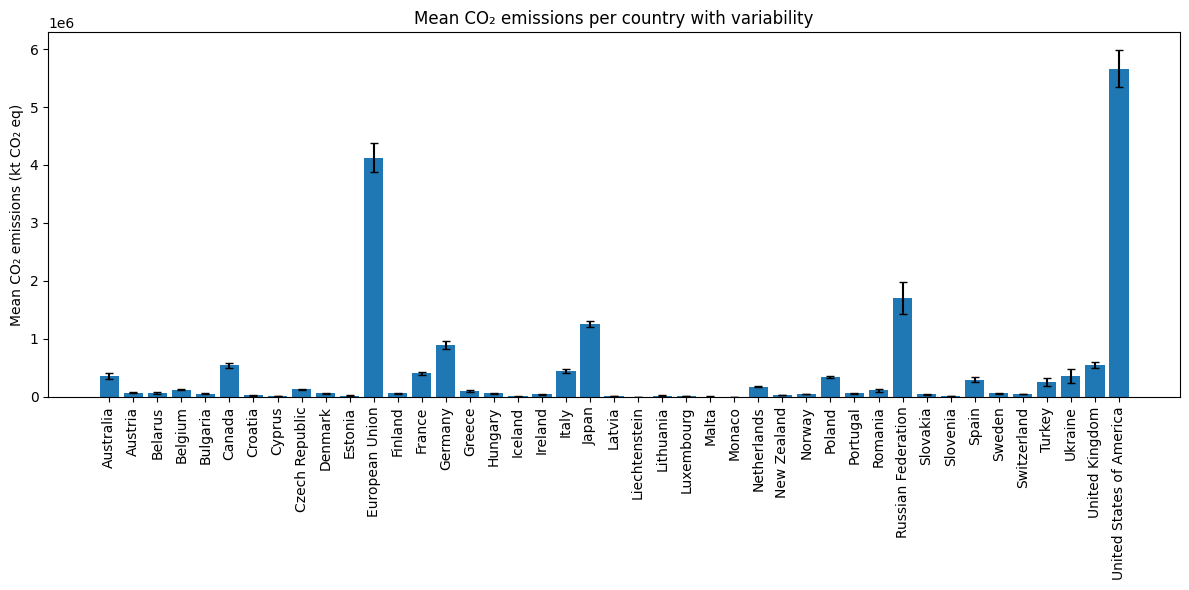

In [9]:
co2 = df[df['category'] ==
         'carbon_dioxide_co2_emissions_without_land_use_land_use_change_and_forestry_lulucf_in_kilotonne_co2_equivalent']

summary = co2.groupby('country_or_area')['value'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(12,6))

plt.bar(
    summary['country_or_area'],
    summary['mean'],
    yerr=summary['std'],
    capsize=3
)

plt.xticks(rotation=90)
plt.ylabel('Mean CO₂ emissions (kt CO₂ eq)')
plt.title('Mean CO₂ emissions per country with variability')
plt.tight_layout()
plt.show()

##### Q3 - Compute the mean, minimum, maximum, quartiles and standard deviation of GHG emmission values of CO<sub>2</sub> (carbon_dioxide_co2_emissions_without_land_use_land_use_change_and_forestry_lulucf_in_kilotonne_co2_equivalent) in 1990 and 2014, and separately for Portugal and Greece.

In [10]:
countries = ['Portugal', 'Greece']
years = [1990, 2014]

co2_subset = co2[co2['country_or_area'].isin(countries) &
                 co2['year'].isin(years)]

def stats(x):
    return {
        'mean': np.mean(x),
        'min': np.min(x),
        'max': np.max(x),
        'q1': np.quantile(x, 0.25),
        'median': np.median(x),
        'q3': np.quantile(x, 0.75),
        'std': np.std(x, ddof=1)
    }

result = co2_subset.groupby(['country_or_area','year'])['value'].apply(stats)
result

country_or_area  year        
Greece           1990  mean      83403.719998
                       min       83403.719998
                       max       83403.719998
                       q1        83403.719998
                       median    83403.719998
                       q3        83403.719998
                       std                NaN
                 2014  mean      79628.274399
                       min       79628.274399
                       max       79628.274399
                       q1        79628.274399
                       median    79628.274399
                       q3        79628.274399
                       std                NaN
Portugal         1990  mean      45809.071410
                       min       45809.071410
                       max       45809.071410
                       q1        45809.071410
                       median    45809.071410
                       q3        45809.071410
                       std                NaN
                 2014  mean      48353.690330
                       min       48353.690330
                       max       48353.690330
                       q1        48353.690330
                       median    48353.690330
                       q3        48353.690330
                       std                NaN
Name: value, dtype: float64

##### Q4 - Produce a plot that shows differences/similarities between the two countries in the GHG annual emission values.

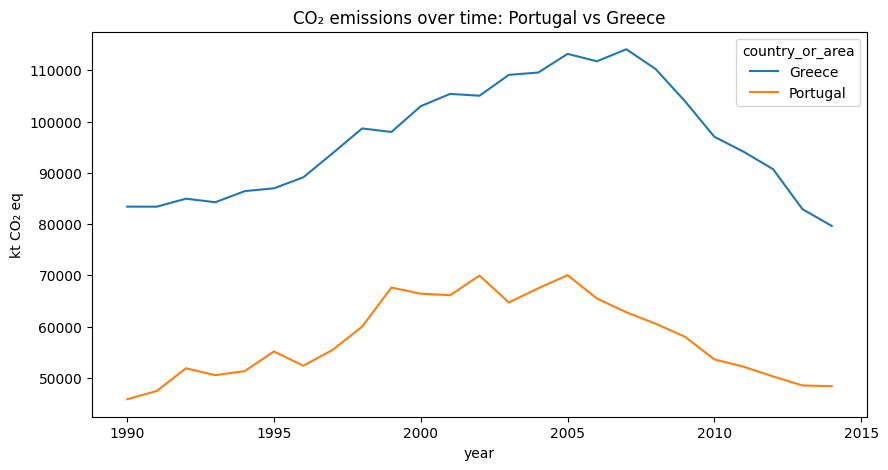

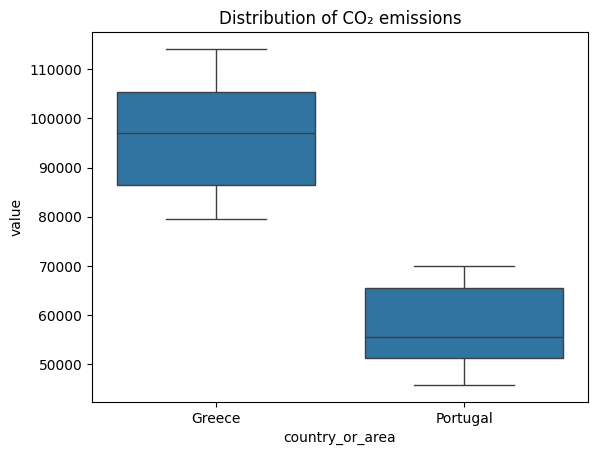

In [11]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=co2[co2['country_or_area'].isin(['Portugal','Greece'])],
    x='year',
    y='value',
    hue='country_or_area'
)

plt.title('CO₂ emissions over time: Portugal vs Greece')
plt.ylabel('kt CO₂ eq')
plt.show()

sns.boxplot(
    data=co2[co2['country_or_area'].isin(['Portugal','Greece'])],
    x='country_or_area',
    y='value'
)
plt.title('Distribution of CO₂ emissions')
plt.show()

##### Q5 - Carefully analyse the central tendency estimates of GHG emmisions you computed on Q3. Is the relationship between the mean and the median the same between countries? Comment your response taking into account the plot produced in Q4.

A relação entre média e mediana permite avaliar assimetria da distribuição. Se a média for superior à mediana, a distribuição tende a ser assimétrica à direita, indicando a presença de anos com emissões excecionalmente elevadas. Se forem semelhantes, a distribuição tende a ser aproximadamente simétrica.

No caso de Portugal e Grécia, a comparação com o gráfico temporal sugere que as emissões não são estáveis ao longo do tempo, apresentando períodos de maior intensidade seguidos de redução. Assim, diferenças entre média e mediana refletem essa variabilidade temporal e possíveis outliers associados a picos de emissão, sendo expectável que a média seja mais sensível a esses valores extremos do que a mediana.

##### Q6 - Assuming that annual CO<sub>2</sub> GHG emission values follow a normal distribution (even if not necessarily true), which statistical test would be appropriate to compare the values between the Portugal and Greece, given the data characteristics? Define the null hypothesis of the test you want to run, the critical *p-value*, run the test and justify briefly your choice.

In [12]:
pt = co2[co2['country_or_area']=='Portugal']['value']
gr = co2[co2['country_or_area']=='Greece']['value']

sts.ttest_ind(pt, gr, equal_var=False)

TtestResult(statistic=np.float64(-14.323031010913827), pvalue=np.float64(5.437506090589905e-18), df=np.float64(43.09678724836844))

##### Q7 - Run an analysis that tests the following null Hypothesis: *H0 - the annual GH Gas Emmision values of Portugal and Greece between 1990 and 2014 follows the same probability distribution*. Use a critical *p-value* of 0.05.

In [13]:
sts.mannwhitneyu(pt, gr, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(0.0), pvalue=np.float64(1.4156562248495537e-09))

##### Q8 - Now imagine you wanted to test if GHG emmission values of CO<sub>2</sub>  changed over the years 1990, 1995, 2000, 2005 and 2010 considering all countries with data. Specify the null and alternative hypothesis of the performed test, the critical alpha used as well as the effect sizes. Check also if the direction of changes in the global emmissions were consistent between the time periods.

In [15]:
years_to_compare = [1990, 1995, 2000, 2005, 2010]
data_for_anova = []

for year in years_to_compare:
    data_for_year = co2[co2['year'] == year]['value'].values
    if len(data_for_year) > 0:
        data_for_anova.append(data_for_year)
    else:
        print(f"Warning: No data found for year {year}")

# Perform the ANOVA F-test
f_statistic, p_value = sts.f_oneway(*data_for_anova)

print(f"Null Hypothesis (H0): There is no significant difference in mean CO₂ emissions across the years {years_to_compare}.")
print(f"Alternative Hypothesis (H1): There is a significant difference in mean CO₂ emissions across at least two of the years {years_to_compare}.")
print(f"Critical alpha: 0.05")
print(f"\nF-statistic: {f_statistic:.3f}")
print(f"P-value: {p_value:.3e}")

# Calculate sum of squares for effect size (Eta-squared)
all_values = np.concatenate(data_for_anova)
grand_mean = np.mean(all_values)

SS_total = np.sum((all_values - grand_mean)**2)
SS_between = 0
for group_data in data_for_anova:
    group_mean = np.mean(group_data)
    n_group = len(group_data)
    SS_between += n_group * (group_mean - grand_mean)**2

eta_squared = SS_between / SS_total

print(f"\nSS_between (Sum of Squares Between Groups): {SS_between:.2f}")
print(f"SS_total (Total Sum of Squares): {SS_total:.2f}")
print(f"Effect Size (Eta-squared): {eta_squared:.3f}")

# Check direction of changes in global emissions
mean_emissions_by_year = {}
for year in years_to_compare:
    mean_emissions_by_year[year] = co2[co2['year'] == year]['value'].mean()

print("\nMean emissions by year:")
for year, mean_val in mean_emissions_by_year.items():
    print(f"Year {year}: {mean_val:.2f}")

print("\nDirection of changes between time periods:")
for i in range(len(years_to_compare) - 1):
    year1 = years_to_compare[i]
    year2 = years_to_compare[i+1]
    mean1 = mean_emissions_by_year[year1]
    mean2 = mean_emissions_by_year[year2]
    change = mean2 - mean1
    direction = "increased" if change > 0 else "decreased" if change < 0 else "remained constant"
    print(f"From {year1} to {year2}: Emissions {direction} by {abs(change):.2f} kt CO₂ eq")

Null Hypothesis (H0): There is no significant difference in mean CO₂ emissions across the years [1990, 1995, 2000, 2005, 2010].
Alternative Hypothesis (H1): There is a significant difference in mean CO₂ emissions across at least two of the years [1990, 1995, 2000, 2005, 2010].
Critical alpha: 0.05

F-statistic: 0.008
P-value: 9.999e-01

SS_between (Sum of Squares Between Groups): 36611375287.00
SS_total (Total Sum of Squares): 246309358433496.25
Effect Size (Eta-squared): 0.000

Mean emissions by year:
Year 1990: 455379.94
Year 1995: 424648.54
Year 2000: 435085.42
Year 2005: 450057.98
Year 2010: 423244.81

Direction of changes between time periods:
From 1990 to 1995: Emissions decreased by 30731.40 kt CO₂ eq
From 1995 to 2000: Emissions increased by 10436.88 kt CO₂ eq
From 2000 to 2005: Emissions increased by 14972.55 kt CO₂ eq
From 2005 to 2010: Emissions decreased by 26813.16 kt CO₂ eq
